# Eksperimen Machine Learning - Credit Card Fraud Detection
**Nama Siswa:** Fierda

Dataset ini berisi transaksi kartu kredit yang dilakukan pada bulan September 2013 oleh pemegang kartu kredit di Eropa. Terdapat 492 penipuan (fraud) dari total 284.807 transaksi. Dataset ini sangat tidak seimbang (highly unbalanced), di mana kelas positif (fraud) hanya menyumbang 0,172% dari semua transaksi. Semua fitur masukan numerik merupakan hasil transformasi PCA (Principal Component Analysis), kecuali fitur 'Time' dan 'Amount'.

**Dataset:** [Credit Card Fraud Detection (Kaggle)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

**Tujuan:** Melakukan eksperimen data preprocessing untuk mempersiapkan dataset yang siap dilatih.

---
## Template Eksperimen MSML
1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Export Dataset Siap Latih

## 1. Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('Libraries imported successfully!')

Libraries imported successfully!


In [4]:
import os
import subprocess
import sys

def get_kaggle_credentials():
    try:
        from google.colab import userdata
        username = userdata.get('KAGGLE_USERNAME')
        key      = userdata.get('KAGGLE_KEY')
        if username and key:
            print('[INFO] Credentials from Colab Secrets.')
            return username, key
    except Exception:
        pass

    username = os.environ.get('KAGGLE_USERNAME')
    key      = os.environ.get('KAGGLE_KEY')
    if username and key:
        print('[INFO] Credentials from environment variables.')
        return username, key

    raise EnvironmentError(
        'KAGGLE_USERNAME / KAGGLE_KEY NOT FOUND!\n\n'
    )

kaggle_username, kaggle_key = get_kaggle_credentials()

os.environ['KAGGLE_USERNAME'] = kaggle_username
os.environ['KAGGLE_KEY']      = kaggle_key

try:
    import kaggle
except ImportError:
    print('[INFO] Installing kaggle...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'kaggle'])
    import kaggle

masked_key = '*' * (len(kaggle_key) - 4) + kaggle_key[-4:]
print(f'[OK] KAGGLE_USERNAME : {kaggle_username}')
print(f'[OK] KAGGLE_KEY      : {masked_key}')

raw_dir  = os.path.join('..', 'creditcard_raw')
os.makedirs(raw_dir, exist_ok=True)
raw_path = os.path.join(raw_dir, 'creditcard.csv')

if not os.path.exists(raw_path):
    print('[INFO] Downloading Kaggle Credit Card Fraud Dataset...')
    kaggle.api.authenticate()
    kaggle.api.dataset_download_files(
        'mlg-ulb/creditcardfraud', path=raw_dir, unzip=True
    )
    print('[OK] Dataset downloaded!')
else:
    print(f'[OK] Dataset already exists: {raw_path}')

[INFO] Credentials from Colab Secrets.
[OK] KAGGLE_USERNAME : popokuppa
[OK] KAGGLE_KEY      : *********************************db60
[OK] Dataset already exists: ../creditcard_raw/creditcard.csv


In [5]:
df = pd.read_csv(raw_path)
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 2. Exploratory Data Analysis (EDA)

### 2.1 Distribusi Target (Class)

Distribusi kelas:
Class
0    284315
1       492
Name: count, dtype: int64

Persentase fraud: 0.1727%


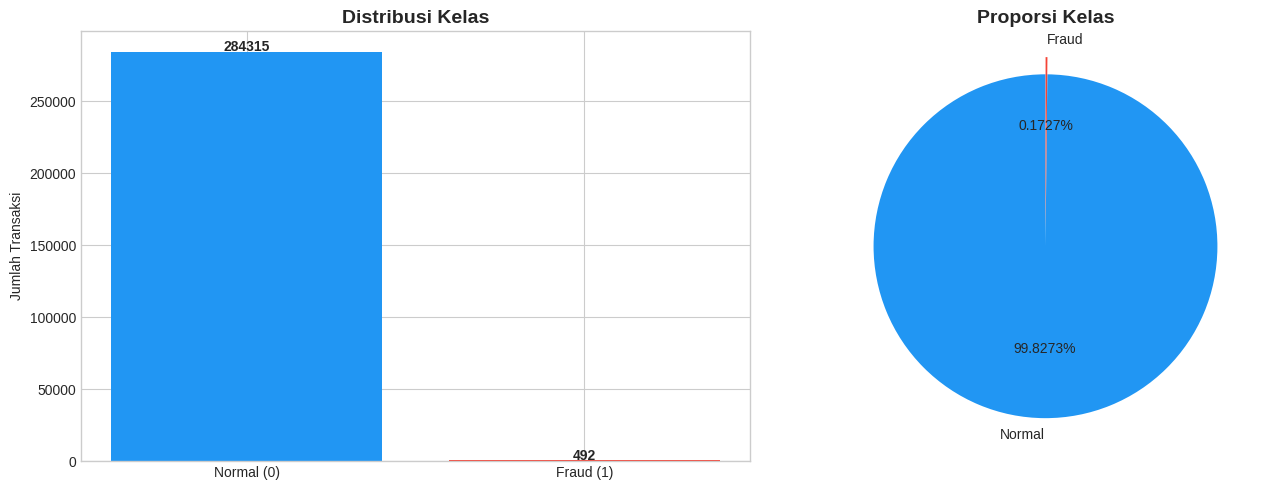

In [8]:
print('Distribusi kelas:')
print(df['Class'].value_counts())
print(f'\nPersentase fraud: {df["Class"].mean()*100:.4f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
counts = df['Class'].value_counts()
ax1.bar(['Normal (0)', 'Fraud (1)'], counts.values, color=['#2196F3', '#F44336'])
ax1.set_title('Distribusi Kelas', fontsize=14, fontweight='bold')
ax1.set_ylabel('Jumlah Transaksi')
for i, v in enumerate(counts.values):
    ax1.text(i, v + 500, str(v), ha='center', fontweight='bold')

ax2 = axes[1]
ax2.pie(counts.values, labels=['Normal', 'Fraud'], autopct='%1.4f%%',
        colors=['#2196F3', '#F44336'], startangle=90, explode=[0, 0.1])
ax2.set_title('Proporsi Kelas', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 2.2 Distribusi Fitur Amount dan Time

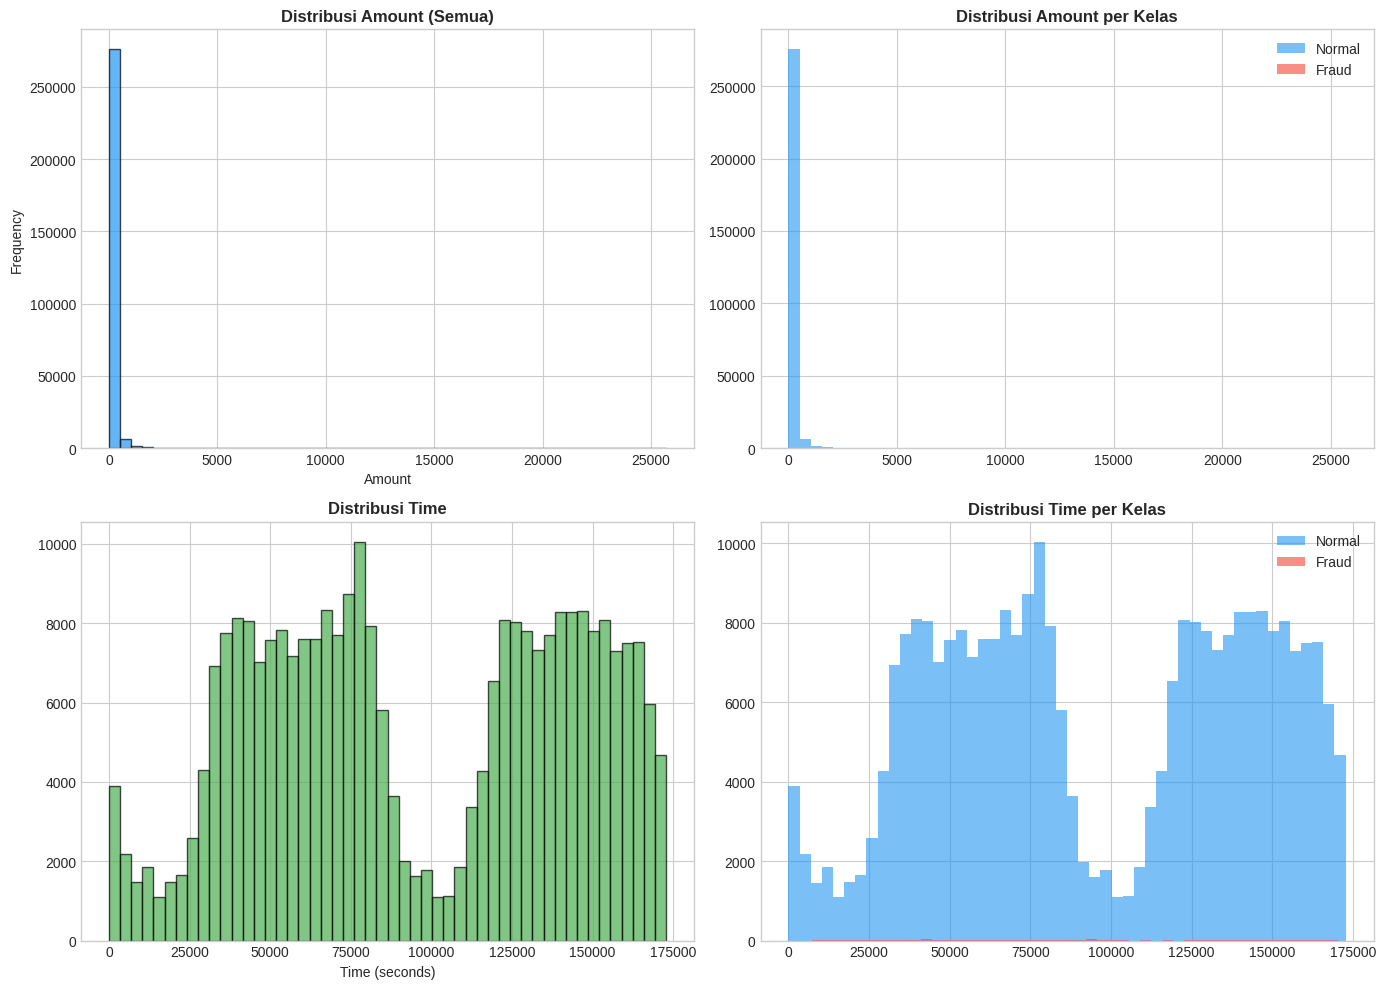

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['Amount'], bins=50, color='#2196F3', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Distribusi Amount (Semua)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Amount')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.6, label='Normal', color='#2196F3')
axes[0, 1].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.6, label='Fraud', color='#F44336')
axes[0, 1].set_title('Distribusi Amount per Kelas', fontsize=12, fontweight='bold')
axes[0, 1].legend()

axes[1, 0].hist(df['Time'], bins=50, color='#4CAF50', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Distribusi Time', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Time (seconds)')

axes[1, 1].hist(df[df['Class']==0]['Time'], bins=50, alpha=0.6, label='Normal', color='#2196F3')
axes[1, 1].hist(df[df['Class']==1]['Time'], bins=50, alpha=0.6, label='Fraud', color='#F44336')
axes[1, 1].set_title('Distribusi Time per Kelas', fontsize=12, fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### 2.3 Korelasi Fitur

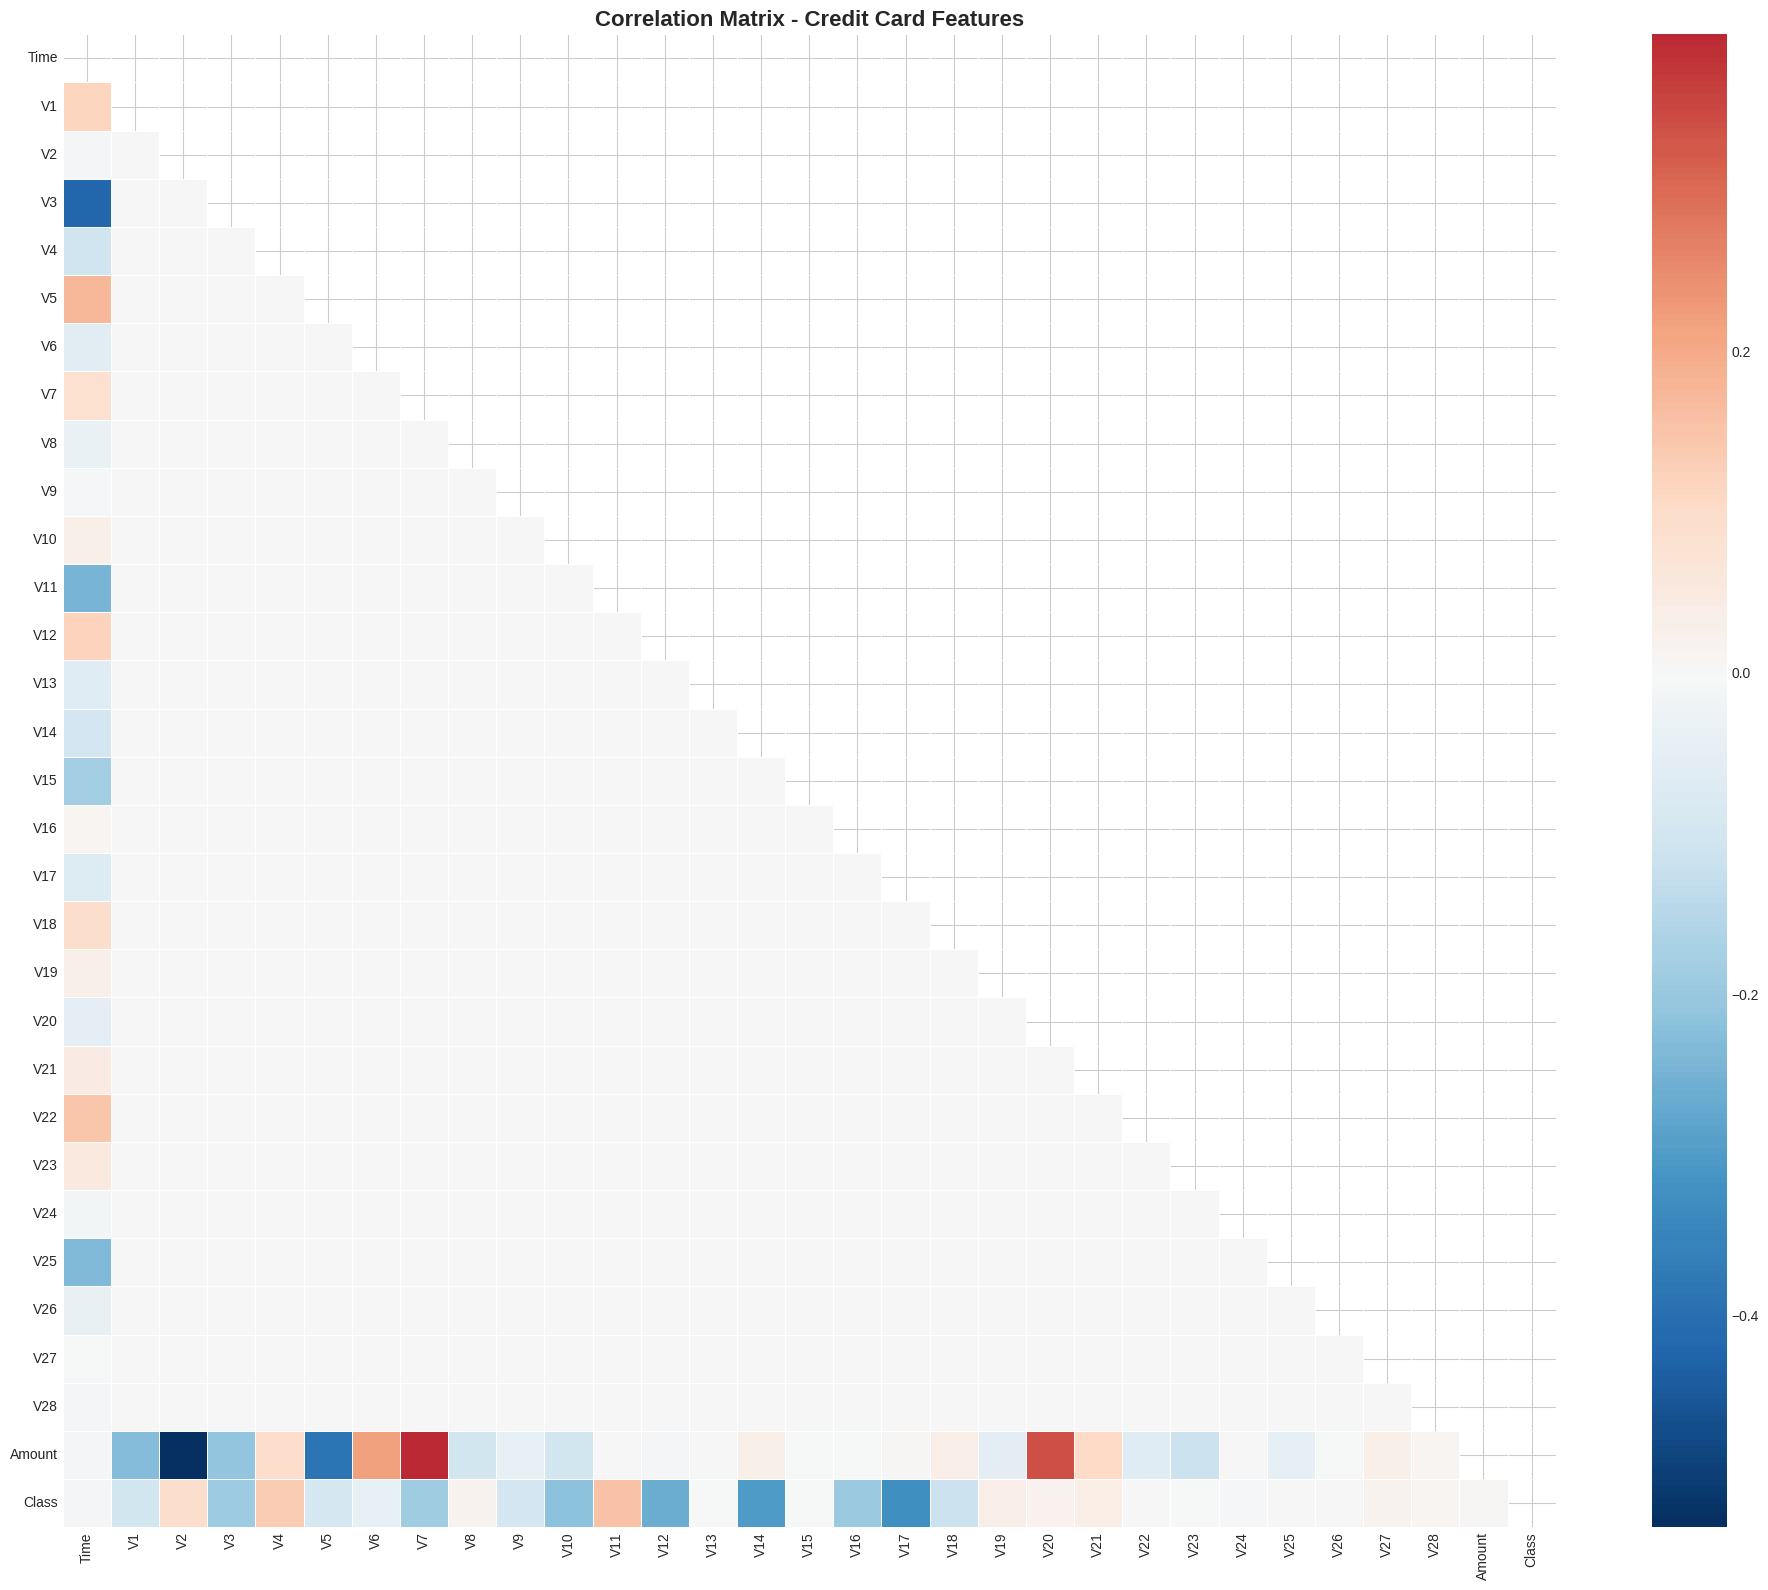

In [10]:
# Correlation matrix
plt.figure(figsize=(20, 16))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix - Credit Card Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Top 10 fitur berkorelasi dengan Class (fraud):
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
Name: Class, dtype: float64


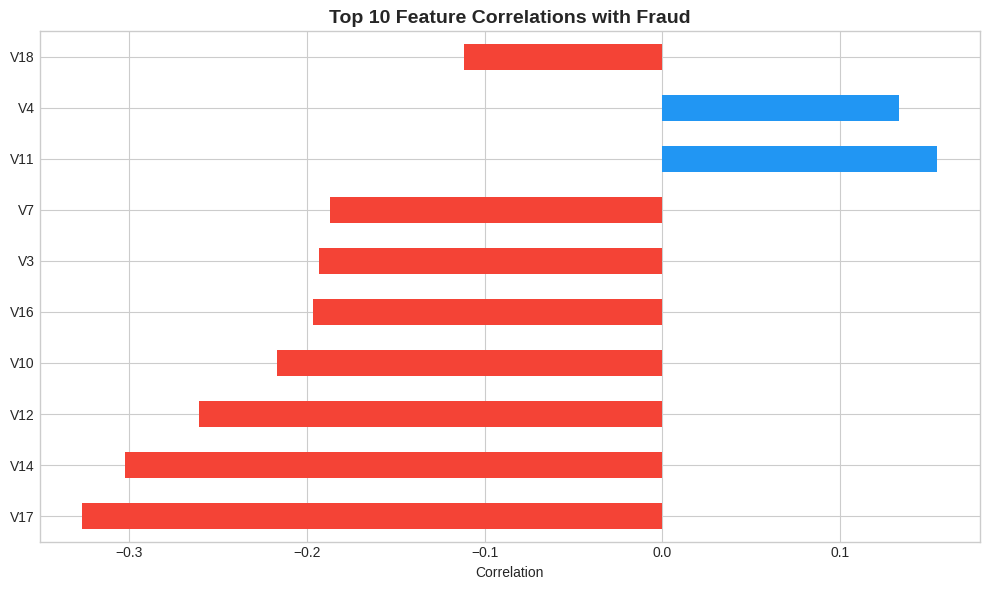

In [11]:
# Top korelasi dengan target
target_corr = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)
print('Top 10 fitur berkorelasi dengan Class (fraud):')
print(target_corr.head(10))

plt.figure(figsize=(10, 6))
target_corr.head(10).plot(kind='barh', color=['#F44336' if x < 0 else '#2196F3' for x in target_corr.head(10)])
plt.title('Top 10 Feature Correlations with Fraud', fontsize=14, fontweight='bold')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

### 2.4 Missing Values & Duplicates

In [12]:
# Check missing values
missing = df.isnull().sum()
print('Missing values per kolom:')
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ada missing values!')
print(f'\nTotal missing: {missing.sum()}')

# Check duplicates
dupes = df.duplicated().sum()
print(f'\nDuplicate rows: {dupes}')

Missing values per kolom:
Tidak ada missing values!

Total missing: 0

Duplicate rows: 1081


### 2.5 Statistik per Kelas

In [13]:
# Statistik Amount per kelas
print('Statistik Amount - Normal vs Fraud:')
print(df.groupby('Class')['Amount'].describe())

print(f'\nRata-rata Amount Normal : ${df[df["Class"]==0]["Amount"].mean():.2f}')
print(f'Rata-rata Amount Fraud  : ${df[df["Class"]==1]["Amount"].mean():.2f}')

Statistik Amount - Normal vs Fraud:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87

Rata-rata Amount Normal : $88.29
Rata-rata Amount Fraud  : $122.21


## 3. Data Preprocessing

Berdasarkan EDA, langkah preprocessing yang perlu dilakukan:
1. Handle missing values (jika ada)
2. Remove duplicate rows
3. Feature scaling pada Amount dan Time
4. Handle class imbalance (undersampling)

### 3.1 Handle Missing Values

In [14]:
df_clean = df.copy()

# Handle missing values
n_missing = df_clean.isnull().sum().sum()
if n_missing > 0:
    df_clean = df_clean.dropna()
    print(f'Dropped {n_missing} missing values. New shape: {df_clean.shape}')
else:
    print('There are no missing values. Proceed to the next step.')

There are no missing values. Proceed to the next step.


### 3.2 Remove Duplicates

In [15]:
n_dupes = df_clean.duplicated().sum()
if n_dupes > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'Dropped {n_dupes} duplicate rows. New shape: {df_clean.shape}')
else:
    print('There are no duplicate rows.')

Dropped 1081 duplicate rows. New shape: (283726, 31)


### 3.3 Feature Scaling

In [16]:
# StandardScaler pada Amount dan Time
scaler = StandardScaler()

df_clean['Amount_scaled'] = scaler.fit_transform(df_clean[['Amount']])
df_clean['Time_scaled'] = scaler.fit_transform(df_clean[['Time']])

# Drop kolom original
df_clean = df_clean.drop(['Amount', 'Time'], axis=1)

print('Feature scaling complete.')
print(f'Columns after scaling: {list(df_clean.columns)}')
print(f'Shape: {df_clean.shape}')
df_clean.head()

Feature scaling complete.
Columns after scaling: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_scaled', 'Time_scaled']
Shape: (283726, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Time_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244200,-1.996823
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342584,-1.996823
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.158900,-1.996802
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.139886,-1.996802
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073813,-1.996781


### 3.4 Handle Class Imbalance (Undersampling)

In [17]:
# Undersampling majority class
fraud = df_clean[df_clean['Class'] == 1]
normal = df_clean[df_clean['Class'] == 0]

print(f'Sebelum balancing:')
print(f'  Normal: {len(normal)}')
print(f'  Fraud : {len(fraud)}')

# Undersample: ambil 3x lipat dari fraud count
n_sample = min(len(fraud) * 3, len(normal))
normal_undersampled = normal.sample(n=n_sample, random_state=42)

df_balanced = pd.concat([normal_undersampled, fraud], axis=0)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nSetelah balancing (undersampling 3:1):')
print(f'  Normal: {len(df_balanced[df_balanced["Class"]==0])}')
print(f'  Fraud : {len(df_balanced[df_balanced["Class"]==1])}')
print(f'  Total : {len(df_balanced)}')

Sebelum balancing:
  Normal: 283253
  Fraud : 473

Setelah balancing (undersampling 3:1):
  Normal: 1419
  Fraud : 473
  Total : 1892


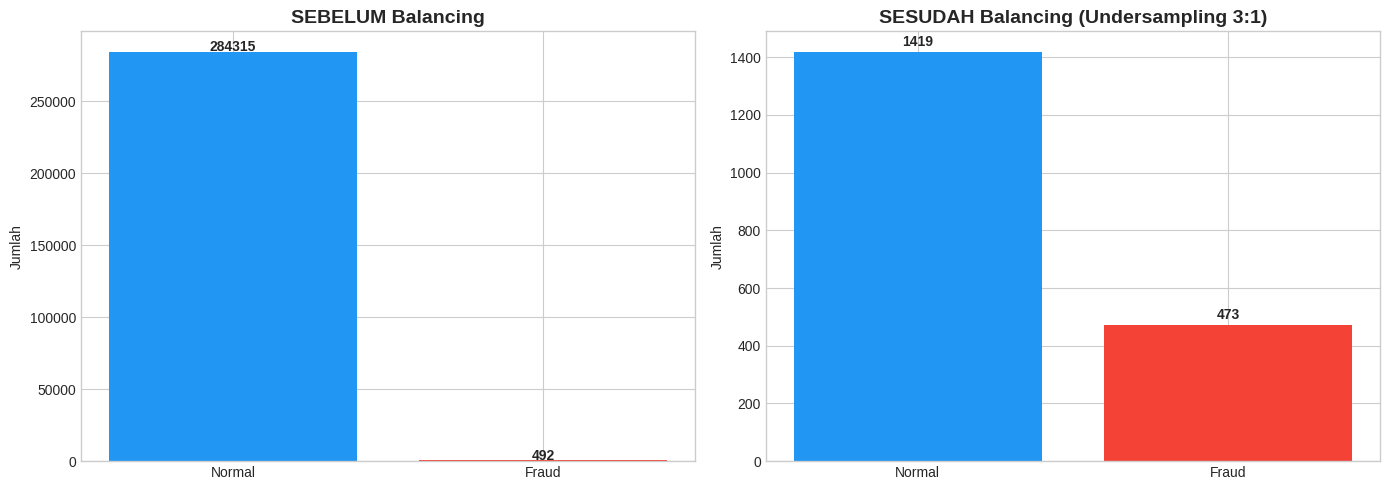

In [18]:
# Visualisasi setelah balancing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
counts_before = df['Class'].value_counts()
axes[0].bar(['Normal', 'Fraud'], counts_before.values, color=['#2196F3', '#F44336'])
axes[0].set_title('SEBELUM Balancing', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(counts_before.values):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# After
counts_after = df_balanced['Class'].value_counts()
axes[1].bar(['Normal', 'Fraud'], counts_after.values, color=['#2196F3', '#F44336'])
axes[1].set_title('SESUDAH Balancing (Undersampling 3:1)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Jumlah')
for i, v in enumerate(counts_after.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Export Dataset Siap Latih

In [19]:
output_path = 'creditcard_preprocessing.csv'
df_balanced.to_csv(output_path, index=False)

print(f'Dataset preprocessed berhasil disimpan!')
print(f'  Path  : {output_path}')
print(f'  Shape : {df_balanced.shape}')
print(f'  Columns: {list(df_balanced.columns)}')

# Verifikasi
df_verify = pd.read_csv(output_path)
print(f'\nVerifikasi load:')
print(f'  Shape: {df_verify.shape}')
print(f'  Class distribution:')
print(df_verify['Class'].value_counts())

Dataset preprocessed berhasil disimpan!
  Path  : creditcard_preprocessing.csv
  Shape : (1892, 31)
  Columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_scaled', 'Time_scaled']

Verifikasi load:
  Shape: (1892, 31)
  Class distribution:
Class
0    1419
1     473
Name: count, dtype: int64
